In [62]:
import cv2
import numpy as np
from mtcnn import MTCNN
from keras_facenet import FaceNet
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [63]:
# MTCNN sẽ tìm vị trí khuôn mặt trong ảnh
detector = MTCNN()

# FaceNet dùng để chuyển khuôn mặt -> vector đặc trưng (embedding 512 chiều)
embedder = FaceNet()

In [64]:
# FUNCTION: detect & crop face
def extract_face(img, required_size=(160,160)):
    """
    Phát hiện khuôn mặt trong ảnh và cắt ra đúng kích thước chuẩn cho FaceNet
    img : numpy array -> ảnh đọc bằng cv2
    required_size : tuple -> kích thước ảnh đầu ra (FaceNet yêu cầu 160x160)
    
    Returns
    face_array : numpy array hoặc None
        trả về ảnh khuôn mặt đã resize
        nếu không detect được mặt → trả về None
    """

    # MTCNN dùng ảnh RGB, trong khi OpenCV đọc ảnh dạng BGR
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # detect khuôn mặt
    results = detector.detect_faces(img_rgb)

    # nếu không phát hiện khuôn mặt
    if len(results) == 0:
        return None

    # lấy bounding box khuôn mặt đầu tiên
    x, y, w, h = results[0]['box']
    
    # tránh lỗi toạ độ âm
    x, y = abs(x), abs(y)
    
    # crop khuôn mặt từ ảnh gốc
    face = img_rgb[y:y+h, x:x+w]
    
    # resize về kích thước chuẩn cho FaceNet
    face = cv2.resize(face, required_size)
    
    return face

In [65]:
# FUNCTION: face -> embedding
def get_embedding(face_img):
    """
    Chuyển ảnh khuôn mặt -> vector đặc trưng (embedding)
    embedding là vector 512 chiều đại diện cho khuôn mặt dùng để so sánh độ giống giữa 2 người
    face_img : numpy array
        ảnh khuôn mặt đã crop (160x160)
    
    Returns
    embedding : numpy array (512,) vector đặc trưng của khuôn mặt
    """

    # chuyển kiểu dữ liệu sang float32
    face_img = face_img.astype('float32')


    # thêm chiều batch vì model yêu cầu input dạng (batch_size, h, w, c)
    samples = np.expand_dims(face_img, axis=0)

    # tạo vector embedding
    embedding = embedder.embeddings(samples)

    # trả về vector 1 chiều (512)
    return embedding[0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Reference embedding created
Embedding shape: (512,)


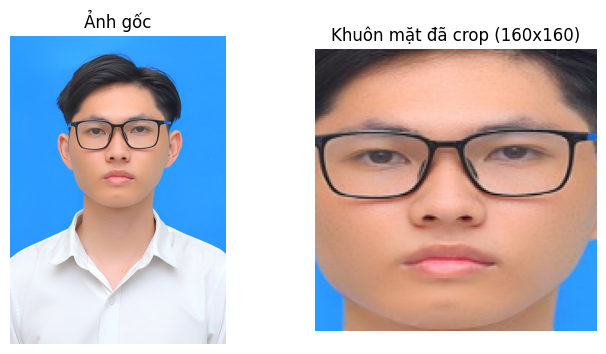

In [66]:
# LOAD REFERENCE IMAGE
#img_path = "face_image_set/Henry Cavill/Henry Cavill_0.jpg"
img_path = "face_image_set/test/reference.jpg"
# đọc ảnh bằng OpenCV
img = cv2.imread(img_path)

# kiểm tra ảnh có load được không
if img is None:
    print("Không tìm thấy ảnh, kiểm tra lại đường dẫn")
else:
    # detect và crop khuôn mặt
    face = extract_face(img)

    # kiểm tra có detect được mặt không
    if face is None:
        print("Không phát hiện khuôn mặt trong ảnh mẫu")
    else:
        # tạo vector embedding cho ảnh mẫu
        reference_embedding = get_embedding(face)

        print("Reference embedding created")
        print("Embedding shape:", reference_embedding.shape)

# OpenCV đọc ảnh theo hệ màu BGR, cần chuyển sang RGB để Matplotlib hiển thị đúng màu
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Tạo một khung vẽ (figure) để chứa 2 bức ảnh cạnh nhau
        plt.figure(figsize=(8, 4))
        
        # Ảnh 1: Ảnh gốc
        plt.subplot(1, 2, 1)
        plt.imshow(img_rgb)
        plt.title("Ảnh gốc")
        plt.axis('off') # Ẩn trục tọa độ
        
        # Ảnh 2: Khuôn mặt đã cắt (Kích thước 160x160)
        # Lưu ý: Hàm extract_face của bạn đã tự chuyển ảnh sang RGB rồi nên không cần convert nữa
        plt.subplot(1, 2, 2)
        # Ép kiểu về int để Matplotlib không báo lỗi cảnh báo màu sắc
        plt.imshow(face.astype('uint8')) 
        plt.title("Khuôn mặt đã crop (160x160)")
        plt.axis('off')
        
        # Hiển thị kết quả
        plt.show()

In [67]:
# REALTIME FACE RECOGNITION + GIAO DIỆN GHÉP MỞ RỘNG (SIDE-BY-SIDE UI)

# mở webcam
cap = cv2.VideoCapture(0)

threshold = 0.7
cap.set(3, 640)
cap.set(4, 480)

# ====================================================================
# 1. CHUẨN BỊ ẢNH REFERENCE (GỐC & ĐÃ CẮT)
# ====================================================================
img_ref = cv2.imread(img_path)

# 1.1 Chuẩn bị ảnh gốc thu nhỏ để hiển thị (200x200)
img_ref_disp = cv2.resize(img_ref, (200, 200))

# 1.2 Chuẩn bị ảnh khuôn mặt mẫu đã cắt
face_ref = extract_face(img_ref)

if face_ref is not None:
    # Hàm extract_face trả về RGB, cần chuyển lại BGR cho OpenCV
    face_ref_bgr = cv2.cvtColor(face_ref, cv2.COLOR_RGB2BGR)
    ref_face_disp = cv2.resize(face_ref_bgr, (200, 200))
else:
    # Fallback nếu lỗi
    ref_face_disp = np.zeros((200, 200, 3), dtype=np.uint8)

print("Press Q to quit")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h_frame, w_frame, _ = frame.shape
    
    # 2. Tạo Panel rộng hơn (450px) để chứa đủ 3 ảnh
    side_panel = np.zeros((h_frame, 450, 3), dtype=np.uint8)

    # ====================================================================
    # LÚC NÀO CŨNG HIỂN THỊ 2 ẢNH REFERENCE (Dù Match hay Unknown)
    # ====================================================================
    # HIỂN THỊ ẢNH GỐC (Góc trên - Bên trái của Panel)
    side_panel[20:220, 15:215] = img_ref_disp
    cv2.putText(side_panel, "Original Ref", (55, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # HIỂN THỊ KHUÔN MẶT MẪU (Góc trên - Bên phải của Panel)
    side_panel[20:220, 235:435] = ref_face_disp
    cv2.putText(side_panel, "Cropped Ref", (275, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    # ====================================================================

    # Detect 1 lần duy nhất
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(frame_rgb)

    if len(results) > 0:
        x, y, w, h = results[0]['box']
        x, y = max(0, x), max(0, y)

        face = frame_rgb[y:y+h, x:x+w]
        
        if face.size > 0:
            face_resized = cv2.resize(face, (160, 160))
            live_embedding = get_embedding(face_resized)

            similarity = cosine_similarity(
                [reference_embedding],
                [live_embedding]
            )[0][0]

            # Kiểm tra ngưỡng (Chỉ đổi Text & Box, không ảnh hưởng hình mẫu nữa)
            if similarity > threshold:
                label = "Matched"
                color = (0, 255, 0)
            else:
                label = "Unknown"
                color = (0, 0, 255)

            # Vẽ bounding box lên khung hình camera
            cv2.rectangle(frame, (x,y), (x+w, y+h), color, 2)
            cv2.putText(frame, f"{label} {similarity:.2f}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

            # HIỂN THỊ KHUÔN MẶT WEBCAM (Căn giữa ở nửa dưới Panel)
            face_disp_resized = cv2.resize(face, (200, 200))
            face_bgr = cv2.cvtColor(face_disp_resized, cv2.COLOR_RGB2BGR)
            
            # Đặt ở giữa: tọa độ X từ 125 đến 325
            side_panel[260:460, 125:325] = face_bgr
            cv2.putText(side_panel, "Live Face", (180, 255), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    # 3. Ghép khung hình Camera và Side Panel lại thành 1 giao diện
    final_interface = np.hstack((frame, side_panel))

    cv2.imshow("Face Recognition System", final_interface)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Press Q to quit
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/s